# S pombe ecDNA analysis

Modification of img-explorer to process _S pombe_ image data, using both nuclear and cell segmentation

In [1]:
# Import necessary packages

import os
import glob
import sys
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
import logging

import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import plotnine as p9
import pandas as pd
from skimage import feature, io
from scipy.stats import norm
from scipy.ndimage import label, find_objects

# Make path for scripts relative to the working directory
sys.path.insert(0, '../src')  # Adjust the path as needed

# Setup basic logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [2]:
# Define path names and data folders to process

# Define the location of the files to read
parent_directory = "/Users/nestor/Documents/NYU-ISG/microscope-data" # data directory
repo_directory = "/Users/nestor/Documents/NYU-ISG/python_image-analysis" # analysis code directory

experiment_list = ["08202025_Taka_pombe-live"]

In [4]:
# Do some housekeeping first

# Define the folder structure within each experiment
file_folders = {
    "image": "MIPs/MIPs_multichannel/", 
    "mask_n": "segmentation-masks/nuclei_masks/",
    "mask_c": "segmentation-masks/whole-cell_masks/"
}

# Load the function img_loadr() 
from load_files import img_loadr

def extract_base_name(filename):
    """
    Extract the base name from the file name without removing important parts of the name,
    such as the date and experiment information, while stripping the channel prefixes from masks.
    """
    name = os.path.basename(filename)

    # Only remove 'C1-', 'C2-', etc., from mask files
    if name.startswith(("C1-", "C2-", "C3-", "C4-", "C5-")):
        name = name[3:]  # Remove the first 3 characters (e.g., 'C1-', 'C2-', etc)
    
    # Remove the "_cp_masks" suffix for masks or ".ome" from image files if present
    name = name.replace("_cp_masks", "").replace(".ome", "")
    
    # Remove the file extension
    base_name = os.path.splitext(name)[0]
    
    return base_name

In [6]:
# CHUNK 1 # 
# Load maximum intensity projection (MIP) files
# and segmentation masks for images in all experiments listed

# Create a dictionary to store data across multiple experiments
all_experiments_data = {}

# Iterate through each experiment in experiment_list
for experiment in experiment_list:
    # Initialize data structures for the current experiment
    exp_data = {
        "all_images": {"image": [], "mask_n": [], "mask_c": []},
        "file_names": {"image": [], "mask_n": [], "mask_c": []},
        "base_names": {"image": [], "mask_n": [], "mask_c": []},
        "errors": []
    }

    # Read in the experimental groups reference file for each experiment
    exp_groups = pd.read_csv(os.path.join(parent_directory, experiment, "experimental-groups.csv"))

    # Process each file type using img_loadr
    with ThreadPoolExecutor(max_workers=4) as executor:
        for f in file_folders:
            file_path = os.path.join(parent_directory, experiment, file_folders[f])
            files = glob.glob(os.path.join(file_path, "*.tif"))
            results = executor.map(img_loadr, files)

            for result in results:
                image, filename = result
                if image is not None:
                    exp_data["all_images"][f].append(image)
                    exp_data["file_names"][f].append(filename)
                    exp_data["base_names"][f].append(extract_base_name(filename))
                else:
                    exp_data["errors"].append(f"Error loading {filename}")

    # Log the completion of processing for this experiment
    if exp_data["errors"]:
        logging.error(f"{experiment}: Completed with errors in {len(exp_data['errors'])} files.")
    else:
        logging.info(f"{experiment}: All images and masks processed successfully without errors.")
    
    # Store the experiment's data under its name
    all_experiments_data[experiment] = exp_data

# Optional: Summary of processed files for all experiments
for experiment, data in all_experiments_data.items():
    logging.info(f"{experiment}: Processed {len(data['file_names']['image'])} images, {len(data['file_names']['mask_n'])} nuclei masks and {len(data['file_names']['mask_c'])} cell masks.")
    
# Now for each experiment, all_images["image"] contains all the images (MIPs), 
# all_images["mask_n"] contains all the nuclei masks and 
# all_images["mask_c"] contains all the cell masks

2025-08-22 16:53:01,384 - INFO - 08202025_Taka_pombe-live: All images and masks processed successfully without errors.
2025-08-22 16:53:01,384 - INFO - 08202025_Taka_pombe-live: Processed 50 images, 50 nuclei masks and 50 cell masks.


In [7]:
# Optional: check dimensions of a given set of images, to verify they're correct

# Define function to check dimensions of images and masks
def img_sizr(image_types, file_indices, all_images):
    for f in file_indices:
        for image_type in image_types:
            try:
                image_shape = all_images[image_type][f].shape
                logging.info(f"File {f} ({image_type}): {image_shape}")
            except IndexError:
                logging.warning(f"File index {f} for {image_type} is out of range.")
            except KeyError:
                logging.error(f"Image type {image_type} does not exist.")

# Define the list of image types to check
image_types_to_check = ['image', 'mask_n', 'mask_c']  # Add 'mask_b' if you want to check background masks too

# And the list of file indices to check
test_files = [3, 4]

# Loop over each experiment in all_experiments_data
for experiment, data in all_experiments_data.items():
    logging.info(f"Running dimension check for experiment: {experiment}")
    img_sizr(image_types_to_check, test_files, data["all_images"])

2025-08-22 16:53:38,758 - INFO - Running dimension check for experiment: 08202025_Taka_pombe-live
2025-08-22 16:53:38,764 - INFO - File 3 (image): (3, 2048, 2048)
2025-08-22 16:53:38,765 - INFO - File 3 (mask_n): (2048, 2048)
2025-08-22 16:53:38,766 - INFO - File 3 (mask_c): (2048, 2048)
2025-08-22 16:53:38,766 - INFO - File 4 (image): (3, 2048, 2048)
2025-08-22 16:53:38,767 - INFO - File 4 (mask_n): (2048, 2048)
2025-08-22 16:53:38,768 - INFO - File 4 (mask_c): (2048, 2048)


In [9]:
# CHUNK 2 #
# Match image indices to mask indices, to make sure they're paired correctly
# as they may not have been read in the same order

# Loop over each experiment in all_experiments_data to match image and mask indices
for experiment, data in all_experiments_data.items():
    logging.info(f"Matching image indices to mask indices for experiment: {experiment}")

    # Access the base names for images and masks in this experiment
    image_base_names = data['base_names']['image']
    nuc_base_names   = data['base_names']['mask_n']   # nuclear masks
    cell_base_names  = data['base_names']['mask_c']   # cell masks

    # Fast lookup: base_name -> index
    img_name_to_idx  = {bn: i for i, bn in enumerate(image_base_names)}
    nuc_name_to_idx  = {bn: i for i, bn in enumerate(nuc_base_names)}
    cell_name_to_idx = {bn: i for i, bn in enumerate(cell_base_names)}

    matched_triples = []
    missing_nuc = 0
    missing_cell = 0
    
    # Match by iterating over images (primary driver)
    for img_idx, bn in enumerate(image_base_names):
        n_idx = nuc_name_to_idx.get(bn)
        c_idx = cell_name_to_idx.get(bn)

        if n_idx is None:
            missing_nuc += 1
            logging.warning(f"[{experiment}] No matching NUCLEAR mask for image base_name='{bn}'")

        if c_idx is None:
            missing_cell += 1
            logging.warning(f"[{experiment}] No matching CELL mask for image base_name='{bn}'")

        # Only keep fully matched triplets
        if (n_idx is not None) and (c_idx is not None):
            matched_triples.append((img_idx, n_idx, c_idx))

    # Masks that don't have a corresponding image (useful for sanity checks)
    nuc_without_image  = sorted(set(nuc_name_to_idx.keys())  - set(img_name_to_idx.keys()))
    cell_without_image = sorted(set(cell_name_to_idx.keys()) - set(img_name_to_idx.keys()))

    # Log summary
    logging.info(
        f"{experiment}: Matched {len(matched_triples)} (image, nuc, cell) triplets. "
        f"Missing nuclear for {missing_nuc} images; missing cell for {missing_cell} images."
    )
    if nuc_without_image:
        logging.info(f"[{experiment}] Nuclear masks with no image match: {len(nuc_without_image)}")
    if cell_without_image:
        logging.info(f"[{experiment}] Cell masks with no image match: {len(cell_without_image)}")

    # Store results for downstream analysis
    data["matched_indices"] = matched_triples
    data["unmatched"] = {
        "images_missing_nuclear": missing_nuc,
        "images_missing_cell": missing_cell,
        "nuc_masks_without_image": nuc_without_image,
        "cell_masks_without_image": cell_without_image,
    }

# Now, data["matched_indices"] contains (img_idx, nuc_mask_idx, cell_mask_idx) triplets per experiment

2025-08-22 17:05:19,146 - INFO - Matching image indices to mask indices for experiment: 08202025_Taka_pombe-live
2025-08-22 17:05:19,147 - INFO - 08202025_Taka_pombe-live: Matched 50 (image, nuc, cell) triplets. Missing nuclear for 0 images; missing cell for 0 images.


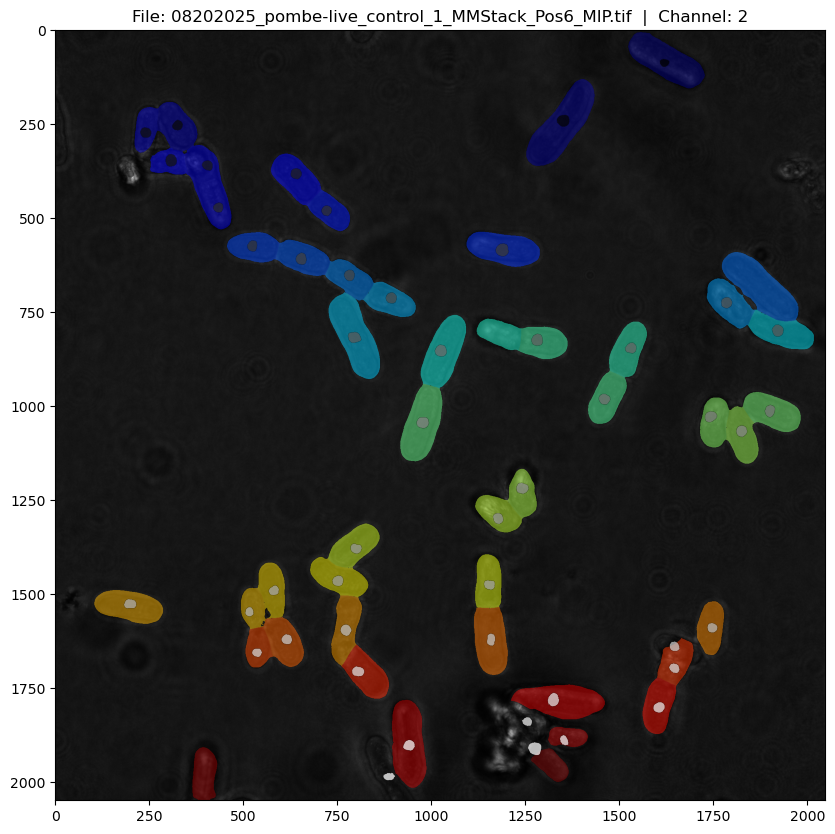

In [16]:
# Overlay the corresponding masks on a channel (given as c) of a given image
# to visually inspect

# Specify the index of the image to check
# and the channel to plot — remember C-1 for ImageJ is channel 0 for Python!
e_index = 0
image_index = 33

# Replace with the desired index
c = 2 # remember the channel order in these images

# Access the specific experiment's data
experiment_key = experiment_list[e_index]
experiment_data = all_experiments_data[experiment_list[e_index]]

# Find the corresponding mask index for the specified image
# and define the image and mask pair
matched_indices = experiment_data["matched_indices"]

try:
    img_idx, nuc_idx, cell_idx = next(trip for trip in matched_indices if trip[0] == image_index)
except StopIteration:
    raise ValueError(f"No matched masks found for image_index={image_index} in experiment '{experiment_key}'")

# Define image and both masks
my_image   = experiment_data['all_images']['image'][image_index]
image_file = experiment_data['file_names']['image'][image_index]
my_mask_n  = experiment_data['all_images']['mask_n'][nuc_idx]
my_mask_c  = experiment_data['all_images']['mask_c'][cell_idx]

# Select the channel to display
channel_image = my_image[c, ...]

# Sanity checks on shapes
if channel_image.shape != my_mask_n.shape or channel_image.shape != my_mask_c.shape:
    print("Warning: The image and one or more masks have different sizes. Please check your data.")
else:
    # Mask background (0) so only labeled regions are drawn
    cell_overlay = np.ma.masked_where(my_mask_c == 0, my_mask_c)
    nuc_overlay  = np.ma.masked_where(my_mask_n == 0, my_mask_n)

    plt.figure(figsize=(10, 10))
    plt.imshow(channel_image, cmap='gray')              # base image in grayscale
    plt.imshow(cell_overlay, cmap='jet', alpha=0.5)    # cell mask in jet
    plt.imshow(nuc_overlay,  cmap='gray', alpha=0.75)    # nuclear mask in grayscale on top
    plt.title(f'File: {image_file}  |  Channel: {c}')
    # plt.axis('off')
    plt.show()

In [20]:
# Create a function that matches nuclear masks to cell masks using pixel overlap

from collections import defaultdict

def assign_nuclei_to_cells(
    nuc_mask: np.ndarray,
    cell_mask: np.ndarray,
    min_overlap_px: int = 0,
    min_overlap_frac: float | None = None
):
    """
    Assign each nucleus (nuc_ID) to the cell (cell_ID) it overlaps the most,
    enforcing a minimum overlap requirement.

    Parameters
    ----------
    nuc_mask : 2D ndarray of int
        Labeled nuclear mask (0 = background, 1..N = nuclei labels).
    cell_mask : 2D ndarray of int
        Labeled cell mask (0 = background, 1..M = cell labels).
    min_overlap_px : int, default=0
        Minimum number of overlapping pixels required to assign a nucleus to a cell.
    min_overlap_frac : float in (0,1], optional
        Minimum fraction of the nucleus area that must overlap a cell to assign.
        If provided alongside min_overlap_px, both conditions must be met.

    Returns
    -------
    dict:
        {
          "nuc_to_cell": {nuc_ID -> cell_ID_or_0},
          "cell_to_nucs": {cell_ID -> [nuc_ID, ...]},
          "unassigned_nuclei": [nuc_ID, ...],
          "empty_cells": [cell_ID, ...],
          "nuc_as_cellID_mask": 2D ndarray (each nucleus pixel = its assigned cell_ID, else 0),
          "n_nuclei": int,
          "n_cells": int,
        }
    """
    if nuc_mask.shape != cell_mask.shape:
        raise ValueError("nuc_mask and cell_mask must have same shape")

    nuc_labels = np.unique(nuc_mask)
    nuc_labels = nuc_labels[nuc_labels != 0]
    cell_labels = np.unique(cell_mask)
    cell_labels = cell_labels[cell_labels != 0]

    nuc_to_cell = {}
    cell_to_nucs = defaultdict(list)
    nuc_as_cellID_mask = np.zeros_like(nuc_mask, dtype=cell_mask.dtype)

    for n_id in nuc_labels:
        n_region = (nuc_mask == n_id)
        n_area = int(n_region.sum())
        overlapped_cells = cell_mask[n_region]
        overlapped_cells = overlapped_cells[overlapped_cells != 0]

        if overlapped_cells.size == 0:
            nuc_to_cell[n_id] = 0
            continue

        unique_cells, counts = np.unique(overlapped_cells, return_counts=True)
        best_idx = int(np.argmax(counts))
        best_cell = int(unique_cells[best_idx])
        best_overlap_px = int(counts[best_idx])

        # Apply minimum-overlap criteria
        passes_px = (best_overlap_px >= min_overlap_px)
        passes_frac = True
        if (min_overlap_frac is not None) and (min_overlap_frac > 0):
            # fraction relative to nucleus area
            passes_frac = (best_overlap_px >= min_overlap_frac * n_area)

        if passes_px and passes_frac:
            nuc_to_cell[n_id] = best_cell
            nuc_as_cellID_mask[n_region] = best_cell
        else:
            nuc_to_cell[n_id] = 0  # unassigned

    # Build reverse mapping and diagnostics
    for n_id, c_id in nuc_to_cell.items():
        if c_id != 0:
            cell_to_nucs[c_id].append(int(n_id))

    empty_cells = [int(c) for c in cell_labels if len(cell_to_nucs.get(int(c), [])) == 0]
    unassigned_nuclei = [int(n) for n, c in nuc_to_cell.items() if c == 0]

    return {
        "nuc_to_cell": nuc_to_cell,
        "cell_to_nucs": dict(cell_to_nucs),
        "unassigned_nuclei": unassigned_nuclei,
        "empty_cells": empty_cells,
        "nuc_as_cellID_mask": nuc_as_cellID_mask,
        "n_nuclei": int(len(nuc_labels)),
        "n_cells": int(len(cell_labels)),
    }

In [29]:
# CHUNK 3 # 
# Map each nucleus to its corresponding cell mask 

# Set your thresholds here
MIN_OVERLAP_PX = 10           # e.g., require ≥10 px overlap
MIN_OVERLAP_FRAC = 0.05       # e.g., require ≥5% of nucleus area to be inside a cell (set None to disable)

for experiment in experiment_list:
    exp_data = all_experiments_data[experiment]
    matched_triples = exp_data["matched_indices"]  # list of (img_idx, nuc_idx, cell_idx)

    exp_results = []  # one entry per matched triple

    total_nuclei = 0
    total_cells = 0
    total_unassigned_nuclei = 0
    total_empty_cells = 0

    for (img_idx, nuc_idx, cell_idx) in matched_triples:
        nuc_mask = exp_data["all_images"]["mask_n"][nuc_idx]
        cell_mask = exp_data["all_images"]["mask_c"][cell_idx]

        if nuc_mask.ndim != 2 or cell_mask.ndim != 2:
            raise ValueError(f"Masks must be 2D label images; got shapes {nuc_mask.shape} and {cell_mask.shape}")

        result = assign_nuclei_to_cells(
            nuc_mask,
            cell_mask,
            min_overlap_px=MIN_OVERLAP_PX,
            min_overlap_frac=MIN_OVERLAP_FRAC
        )

        exp_results.append({
            "image_index": img_idx,
            "nuc_index": nuc_idx,
            "cell_index": cell_idx,
            **result,
        })

        total_nuclei += result["n_nuclei"]
        total_cells += result["n_cells"]
        total_unassigned_nuclei += len(result["unassigned_nuclei"])
        total_empty_cells += len(result["empty_cells"])

    # Store per-experiment results
    exp_data["nuc_cell_assignments"] = exp_results

    # Single compact summary per experiment
    logging.info(
        f"[{experiment}] Summary: nuclei={total_nuclei}, cells={total_cells}, "
        f"unassigned_nuclei={total_unassigned_nuclei}, empty_cells={total_empty_cells} "
        f"(min_overlap_px={MIN_OVERLAP_PX}, min_overlap_frac={MIN_OVERLAP_FRAC})"
    )

NameError: name 'base_name' is not defined

In [34]:
# Write a function to turn the mapping into a data frame

def map_to_df(exp_results, experiment_name, exp_data):
    """
    Convert nucleus→cell assignment results for one experiment into a tidy DataFrame.
    Includes base_name for each image.
    
    exp_results = list of dicts (from exp_data["nuc_cell_assignments"])
    experiment_name = str
    exp_data = the experiment_data dict (to look up base_names)
    """
    rows = []
    for res in exp_results:
        img_idx = res["image_index"]
        base_name = exp_data["base_names"]["image"][img_idx]  # <-- lookup base_name

        nuc_to_cell = res["nuc_to_cell"]
        for nuc_id, cell_id in nuc_to_cell.items():
            rows.append({
                "experiment": experiment_name,
                "image_index": img_idx,
                "base_name": base_name, 
                "nuc_ID": int(nuc_id),
                "cell_ID": int(cell_id) if cell_id != 0 else None,  # None = unassigned
                "assigned": (cell_id != 0),
            })
    return pd.DataFrame(rows)

In [36]:
# Convert nucleus -> cell mapping into a data frame

all_assignments_df = []

for experiment in experiment_list:
    exp_data = all_experiments_data[experiment]
    exp_results = exp_data["nuc_cell_assignments"]
    df_exp = map_to_df(exp_results, experiment, exp_data)
    all_assignments_df.append(df_exp)

all_assignments_df = pd.concat(all_assignments_df, ignore_index=True)

# Inspect
print(all_assignments_df.head(40))

                  experiment  image_index  \
0   08202025_Taka_pombe-live            0   
1   08202025_Taka_pombe-live            0   
2   08202025_Taka_pombe-live            0   
3   08202025_Taka_pombe-live            0   
4   08202025_Taka_pombe-live            0   
5   08202025_Taka_pombe-live            0   
6   08202025_Taka_pombe-live            0   
7   08202025_Taka_pombe-live            0   
8   08202025_Taka_pombe-live            0   
9   08202025_Taka_pombe-live            0   
10  08202025_Taka_pombe-live            0   
11  08202025_Taka_pombe-live            0   
12  08202025_Taka_pombe-live            0   
13  08202025_Taka_pombe-live            0   
14  08202025_Taka_pombe-live            0   
15  08202025_Taka_pombe-live            0   
16  08202025_Taka_pombe-live            0   
17  08202025_Taka_pombe-live            0   
18  08202025_Taka_pombe-live            0   
19  08202025_Taka_pombe-live            0   
20  08202025_Taka_pombe-live            0   
21  082020